In [152]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import copy
import random
import math

from sqlalchemy import create_engine
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import CSVLogger
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer
from sklearn.cluster import KMeans

from datetime import datetime

In [2]:
dbConnectionString = "sqlite:///baseball_info.db"

engine = create_engine(dbConnectionString)

In [33]:
timeSeriesHittingQuery = "SELECT SeasonStatsHitting.playerId,season,Bios.dob,plateAppearances,atBats,runs,hits,singles,doubles,triples,homeRuns,rbis,sacHits,sacFlies,hitByPitch,walks,intentionalWalks,strikeOuts,stolenBases,caughtStealing,groundedIntoDoublePlays,catcherInterference,battingAverage,onBasePercentage,sluggingPercentage,onBasePlusSlugging,runsPerTob,rbisPerBip,babip,spd,groundBallPercentage,flyBallPercentage,lineDrivePercentage,popUpPercentage FROM SeasonStatsHitting INNER JOIN Bios on Bios.playerId = SeasonStatsHitting.playerId WHERE season BETWEEN 2015 and 2025 and season != 2020 ORDER BY SeasonStatsHitting.playerId,season"

df = pd.read_sql(timeSeriesHittingQuery, engine)

In [34]:
hasMultipleSeasons = df["playerId"].value_counts() > 1
df = df[df["playerId"].isin(hasMultipleSeasons[hasMultipleSeasons].index)]

In [35]:
df.drop(df[df['plateAppearances'] == 0].index, inplace=True)

In [36]:
def calculate_age_from_timestamps(birth_timestamp, current_timestamp):
    birth_date   = datetime.fromtimestamp(birth_timestamp)
    current_date = datetime.fromtimestamp(current_timestamp)

    age = current_date.year - birth_date.year

    # Adjust age if the birthday hasn't occurred yet in the current year
    if (current_date.month, current_date.day) < (birth_date.month, birth_date.day):
        age -= 1
    
    return age

In [37]:
twentyFifteenDateString     = "2015-04-05 00:00:00"
twentySixteenDateString     = "2016-04-03 00:00:00"
twentySeventeenDateString   = "2017-04-02 00:00:00"
twentyEighteenDateString    = "2018-03-29 00:00:00"
twentyNineteenDateString    = "2019-03-20 00:00:00"
twentyTwentyOneDateString   = "2021-04-01 00:00:00"
twentyTwentyTwoDateString   = "2022-04-07 00:00:00"
twentyTwentyThreeDateString = "2023-03-30 00:00:00"
twentyTwentyFourDateString  = "2024-03-20 00:00:00"
twentyTwentyFiveDateString  = "2025-03-18 00:00:00"

# Parse the string into a datetime object
twentyFifteenDateString     = datetime.strptime(twentyFifteenDateString     , "%Y-%m-%d %H:%M:%S")
twentySixteenDateString     = datetime.strptime(twentySixteenDateString     , "%Y-%m-%d %H:%M:%S")
twentySeventeenDateString   = datetime.strptime(twentySeventeenDateString   , "%Y-%m-%d %H:%M:%S")
twentyEighteenDateString    = datetime.strptime(twentyEighteenDateString    , "%Y-%m-%d %H:%M:%S")
twentyNineteenDateString    = datetime.strptime(twentyNineteenDateString    , "%Y-%m-%d %H:%M:%S")
twentyTwentyOneDateString   = datetime.strptime(twentyTwentyOneDateString   , "%Y-%m-%d %H:%M:%S")
twentyTwentyTwoDateString   = datetime.strptime(twentyTwentyTwoDateString   , "%Y-%m-%d %H:%M:%S")
twentyTwentyThreeDateString = datetime.strptime(twentyTwentyThreeDateString , "%Y-%m-%d %H:%M:%S")
twentyTwentyFourDateString  = datetime.strptime(twentyTwentyFourDateString  , "%Y-%m-%d %H:%M:%S")
twentyTwentyFiveDateString  = datetime.strptime(twentyTwentyFiveDateString  , "%Y-%m-%d %H:%M:%S")

# Convert to Unix timestamp
twentyFifteenTimeStamp     = int(twentyFifteenDateString     .timestamp())
twentySixteenTimeStamp     = int(twentySixteenDateString     .timestamp())
twentySeventeenTimeStamp   = int(twentySeventeenDateString   .timestamp())
twentyEighteenTimeStamp    = int(twentyEighteenDateString    .timestamp())
twentyNineteenTimeStamp    = int(twentyNineteenDateString    .timestamp())
twentyTwentyOneTimeStamp   = int(twentyTwentyOneDateString   .timestamp())
twentyTwentyTwoTimeStamp   = int(twentyTwentyTwoDateString   .timestamp())
twentyTwentyThreeTimeStamp = int(twentyTwentyThreeDateString .timestamp())
twentyTwentyFourTimeStamp  = int(twentyTwentyFourDateString  .timestamp())
twentyTwentyFiveTimeStamp  = int(twentyTwentyFiveDateString  .timestamp())

seasonToStartTimeStamp = {}

seasonToStartTimeStamp[2015] = twentyFifteenTimeStamp   
seasonToStartTimeStamp[2016] = twentySixteenTimeStamp   
seasonToStartTimeStamp[2017] = twentySeventeenTimeStamp   
seasonToStartTimeStamp[2018] = twentyEighteenTimeStamp   
seasonToStartTimeStamp[2019] = twentyNineteenTimeStamp   
seasonToStartTimeStamp[2021] = twentyTwentyOneTimeStamp  
seasonToStartTimeStamp[2022] = twentyTwentyTwoTimeStamp  
seasonToStartTimeStamp[2023] = twentyTwentyThreeTimeStamp
seasonToStartTimeStamp[2024] = twentyTwentyFourTimeStamp 
seasonToStartTimeStamp[2025] = twentyTwentyFiveTimeStamp

In [38]:
df['dob'] = df.apply(lambda row: calculate_age_from_timestamps(row['dob'], seasonToStartTimeStamp[row['season']]), axis=1)

In [60]:
def getWindowedFeaturesAndLabels(frame, maxWindowSize):
    frameArray = frame.values.tolist()

    inputs = []
    labels = []
    
    r = 0

    curWindow = []

    playerId = frameArray[0][0]
    
    while r < len(frameArray):
        curPlayerId = frameArray[r][0]

        if curPlayerId != playerId:
            window = []
            
            windowR = 0

            while windowR <= len(curWindow):
                if len(window) == maxWindowSize or windowR == len(curWindow):
                    label = window.pop()

                    labelTest = copy.deepcopy(label)

                    relevantLabels = labelTest[5:6] + labelTest[10:12] + labelTest[18:19] + labelTest[23:24]

                    if len(window) < maxWindowSize - 1:
                        diff = maxWindowSize - 1 - len(window)

                        while diff > 0:
                            padding = [0] * 34
                            window.append(padding)

                            diff -= 1

                    windowArray = [inner_list[2:] for inner_list in window]

                    inputs.append(copy.deepcopy(windowArray))
                    labels.append(copy.deepcopy(relevantLabels))

                    window.append(label)
                    window.pop(0)

                if windowR < len(curWindow):
                    window.append(curWindow[windowR])
                
                windowR += 1

            curWindow = []
            playerId  = curPlayerId

        curWindow.append(frameArray[r])

        r += 1

    return inputs,labels

In [61]:
features,labels = getWindowedFeaturesAndLabels(df, 4)

In [62]:
fullFeaturesArray = np.array(features)
fullLabelsArray   = np.array(labels)

In [63]:
fullFeaturesArray[:,0]

array([[4.10000000e+01, 6.40000000e+01, 5.80000000e+01, ...,
        5.12820513e-02, 1.79487179e-01, 7.69230769e-02],
       [3.90000000e+01, 6.14000000e+02, 5.28000000e+02, ...,
        2.55656109e-01, 2.87330317e-01, 8.14479638e-02],
       [3.90000000e+01, 6.20000000e+02, 5.23000000e+02, ...,
        2.49350649e-01, 2.49350649e-01, 6.49350649e-02],
       ...,
       [2.00000000e+01, 3.20000000e+01, 3.00000000e+01, ...,
        1.00000000e-01, 2.50000000e-01, 1.50000000e-01],
       [2.10000000e+01, 1.03000000e+02, 9.20000000e+01, ...,
        1.66666667e-01, 2.73809524e-01, 3.57142857e-02],
       [2.90000000e+01, 5.80000000e+02, 5.37000000e+02, ...,
        1.94323144e-01, 2.13973799e-01, 4.14847162e-02]], shape=(3799, 32))

In [64]:
runBins              = np.linspace(min(fullLabelsArray[:,0]), max(fullLabelsArray[:,0]), num=4)
homeRunsBins         = np.linspace(min(fullLabelsArray[:,1]), max(fullLabelsArray[:,1]), num=4)
rbiBins              = np.linspace(min(fullLabelsArray[:,2]), max(fullLabelsArray[:,2]), num=4)
stolenBaseBins       = np.linspace(min(fullLabelsArray[:,3]), max(fullLabelsArray[:,3]), num=4)
onBasePercentageBins = np.linspace(min(fullLabelsArray[:,4]), max(fullLabelsArray[:,4]), num=4)

runsBinned             = np.digitize(fullLabelsArray[:,0], runBins, right=True)
homeRunsBinned         = np.digitize(fullLabelsArray[:,1], homeRunsBins, right=True)
rbisBinned             = np.digitize(fullLabelsArray[:,2], rbiBins, right=True)
stolenBasesBinned      = np.digitize(fullLabelsArray[:,3], stolenBaseBins, right=True)
onBasePercentageBinned = np.digitize(fullLabelsArray[:,4], onBasePercentageBins, right=True)

fullLabelsArrayBinned = np.column_stack((runsBinned, homeRunsBinned, rbisBinned, stolenBasesBinned, onBasePercentageBinned))

In [69]:
fullLabelsArrayBinned.shape

(3799, 5)

In [71]:
binCount = {}

for label in fullLabelsArrayBinned:
    labelString = str(label[0]) + str(label[1]) + str(label[2]) + str(label[3]) + str(label[4])

    if labelString in binCount:
        binCount[labelString] = binCount[labelString] + 1
    else:
        binCount[labelString] = 1

In [79]:
sortedBinCount = dict(sorted(binCount.items(), key=lambda item: item[1], reverse=True))

In [83]:
len(sortedBinCount)

90

In [102]:
binOne   = {}
binTwo   = {}
binThree = {}
binFour  = {}

index = 1

for key in sortedBinCount:
    if index <= 22:
        binOne[key] = sortedBinCount[key]
    elif index > 22 and index <= 44:
        binTwo[key] = sortedBinCount[key]
    elif index > 44 and index <= 66:
        binThree[key] = sortedBinCount[key]
    else:
        binFour[key] = sortedBinCount[key]

    index += 1

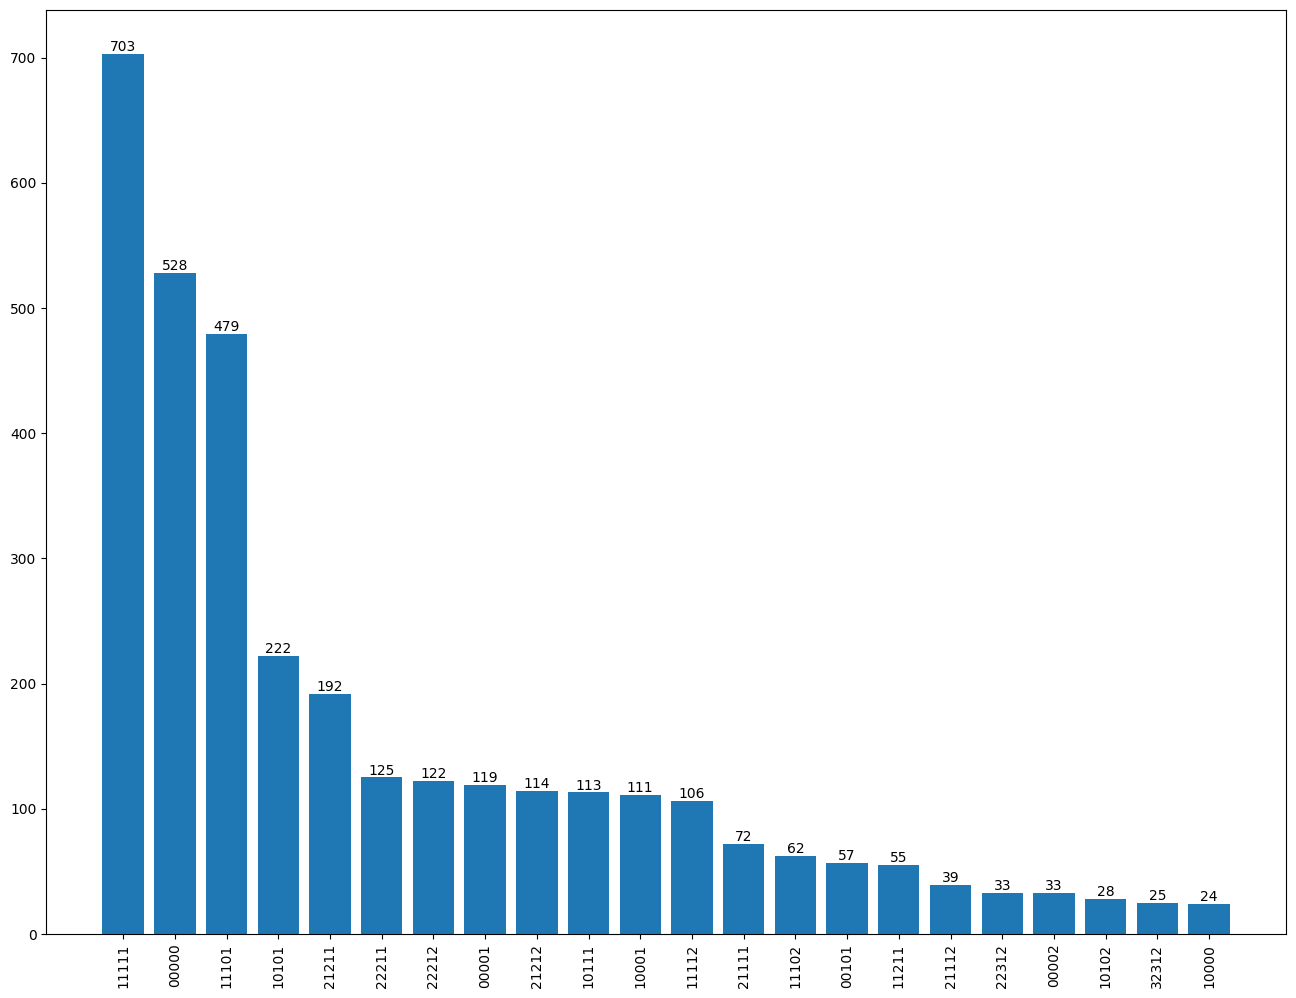

In [104]:
labels = list(binOne.keys())
count  = list(binOne.values())

plt.figure(figsize=(16, 12))
bar = plt.bar(labels, count)

_ = plt.xticks(labels, rotation="vertical")
_ = plt.bar_label(bar, count)

In [144]:
condition = (fullLabelsArrayBinned[:, 0] == 1) & (fullLabelsArrayBinned[:, 1] == 1) & (fullLabelsArrayBinned[:, 2] == 1) & (fullLabelsArrayBinned[:, 3] == 0) & (fullLabelsArrayBinned[:, 4] == 1)

matchingLabelIndices = np.where(condition)[0]

len(matchingLabelIndices)

479

In [164]:
fullFeaturesArray[411]

array([[3.10000000e+01, 2.93000000e+02, 2.31000000e+02, 4.50000000e+01,
        5.60000000e+01, 3.20000000e+01, 1.00000000e+01, 1.00000000e+00,
        1.30000000e+01, 4.20000000e+01, 0.00000000e+00, 0.00000000e+00,
        3.00000000e+00, 5.90000000e+01, 4.00000000e+00, 6.70000000e+01,
        1.00000000e+00, 1.00000000e+00, 9.00000000e+00, 0.00000000e+00,
        2.42424242e-01, 4.02730375e-01, 4.63203463e-01, 8.65933839e-01,
        3.04761905e-01, 1.43410596e-01, 2.84768212e-01, 3.05769874e+00,
        4.81707317e-01, 2.62195122e-01, 1.89024390e-01, 6.70731707e-02],
       [3.20000000e+01, 5.44000000e+02, 4.69000000e+02, 7.80000000e+01,
        1.14000000e+02, 5.60000000e+01, 3.30000000e+01, 0.00000000e+00,
        2.50000000e+01, 6.80000000e+01, 0.00000000e+00, 7.00000000e+00,
        2.00000000e+00, 6.60000000e+01, 0.00000000e+00, 1.13000000e+02,
        4.00000000e+00, 1.00000000e+00, 1.00000000e+01, 0.00000000e+00,
        2.43070362e-01, 3.34558824e-01, 4.73347548e-01, 8.07906

In [146]:
matchingFeatures = fullFeaturesArray[matchingLabelIndices]
matchingLabels   = fullLabelsArray  [matchingLabelIndices]

In [156]:
matchingFeatureLen   = matchingFeatures.shape[0]
matchingFeatures2d   = matchingFeatures.reshape(matchingFeatureLen, -1)

In [154]:
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto")

In [159]:
kmeans.fit(matchingFeatures2d)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [160]:
kmeans.labels_

array([0, 2, 0, 1, 1, 1, 0, 0, 2, 0, 2, 1, 1, 2, 0, 0, 0, 2, 1, 0, 0, 2,
       1, 1, 1, 2, 1, 3, 2, 1, 3, 2, 0, 2, 2, 0, 3, 3, 1, 2, 3, 1, 1, 0,
       3, 2, 0, 0, 0, 0, 1, 0, 0, 0, 3, 3, 3, 1, 1, 1, 1, 2, 3, 2, 0, 3,
       3, 2, 1, 1, 1, 1, 2, 2, 3, 3, 2, 3, 0, 1, 2, 3, 2, 3, 3, 0, 1, 0,
       1, 1, 2, 1, 0, 1, 2, 2, 0, 3, 0, 3, 1, 1, 2, 0, 0, 1, 3, 0, 0, 1,
       3, 0, 1, 0, 0, 1, 0, 3, 2, 0, 1, 0, 3, 0, 0, 0, 0, 3, 2, 3, 2, 1,
       0, 1, 3, 1, 1, 0, 1, 1, 2, 0, 1, 1, 0, 3, 2, 1, 2, 1, 0, 2, 0, 1,
       1, 0, 0, 1, 1, 3, 0, 3, 2, 3, 3, 0, 1, 3, 0, 3, 0, 0, 3, 1, 0, 0,
       1, 3, 1, 3, 0, 3, 1, 0, 0, 0, 1, 1, 0, 3, 0, 1, 0, 0, 0, 3, 0, 0,
       0, 3, 0, 0, 1, 3, 1, 1, 1, 1, 0, 3, 1, 1, 1, 3, 2, 1, 1, 2, 1, 1,
       1, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 3, 3, 2, 2, 3, 3, 0,
       2, 3, 0, 0, 0, 0, 1, 2, 1, 0, 0, 3, 0, 3, 2, 2, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 3, 2, 1, 2, 3, 2, 0, 1, 3, 2, 0, 2, 1, 3, 0, 0, 2, 3, 0,
       0, 0, 1, 0, 3, 0, 1, 1, 2, 0, 3, 1, 0, 1, 1,

In [161]:
distances = kmeans.transform(samples2d)

In [162]:
distances

array([[ 428.18917731,  977.54617412,  470.27793271,  708.60144243],
       [ 642.45485757,  964.63047047,  474.88995041,  828.94175342],
       [ 165.36120052, 1071.43671054,  610.11441386,  637.84584091],
       ...,
       [ 457.98305207,  857.8063631 ,  561.8633601 ,  480.8541808 ],
       [ 145.82424682, 1169.65581582,  751.78102871,  663.36701853],
       [ 157.32290351, 1180.54622912,  766.79516352,  668.8593367 ]],
      shape=(479, 4))

In [163]:
kmeans.cluster_centers_

array([[2.57821782e+01, 1.04500000e+02, 9.43415842e+01, 1.02524752e+01,
        2.16683168e+01, 1.41584158e+01, 4.41584158e+00, 4.20792079e-01,
        2.67326733e+00, 1.05099010e+01, 8.86138614e-01, 5.04950495e-01,
        1.03465347e+00, 7.73267327e+00, 3.21782178e-01, 2.63217822e+01,
        4.05940594e-01, 2.47524752e-01, 2.04950495e+00, 2.97029703e-02,
        2.08695021e-01, 2.72240095e-01, 3.40259314e-01, 6.12499409e-01,
        2.83447059e-01, 8.41333380e-02, 2.68462134e-01, 2.21283266e+00,
        4.59993188e-01, 2.15467624e-01, 2.28994573e-01, 7.56088378e-02,
        1.85247525e+01, 7.06782178e+01, 6.35099010e+01, 7.05445545e+00,
        1.39009901e+01, 9.05445545e+00, 2.76237624e+00, 2.47524752e-01,
        1.83663366e+00, 7.15346535e+00, 9.10891089e-01, 4.15841584e-01,
        5.44554455e-01, 5.29702970e+00, 1.33663366e-01, 1.82029703e+01,
        3.61386139e-01, 2.02970297e-01, 1.35148515e+00, 1.98019802e-02,
        1.44565051e-01, 1.83845749e-01, 2.30657577e-01, 4.145033

In [148]:
def getDistance(featureArrayOne, featureArrayTwo):
    totalDistance = 0.0
    for i in range(len(featureArrayOne)):
        for j in range(len(featureArrayOne[i])):
            featureOne = featureArrayOne[i][j]
            featureTwo = featureArrayTwo[i][j]

            totalDistance += math.sqrt(math.pow(featureTwo - featureOne, 2))

    return totalDistance

In [149]:
minDistance = 1000000.0
minDistanceI = -1
minDistanceJ = -1

maxDistance = 0.0
maxDistanceI = -1
maxDistanceJ = -1

for i in range(len(matchingFeatures)):
    for j in range(i+1, len(matchingFeatures)):
        eucDistance = getDistance(matchingFeatures[i], matchingFeatures[j])

        if eucDistance < minDistance:
            minDistance = eucDistance
            minDistanceI = i
            minDistanceJ = j

        if eucDistance > maxDistance:
            maxDistance = eucDistance
            maxDistanceI = i
            maxDistanceJ = j
            

print(f"{minDistance}, {minDistanceI}, {minDistanceJ}")
print(f"{maxDistance}, {maxDistanceI}, {maxDistanceJ}")

0.0, 411, 420
5886.292281991077, 362, 411


In [150]:
#REPLACE MASK WITH ALL MINUS 1

matchingFeatures[411]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [151]:
matchingFeatures[420]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

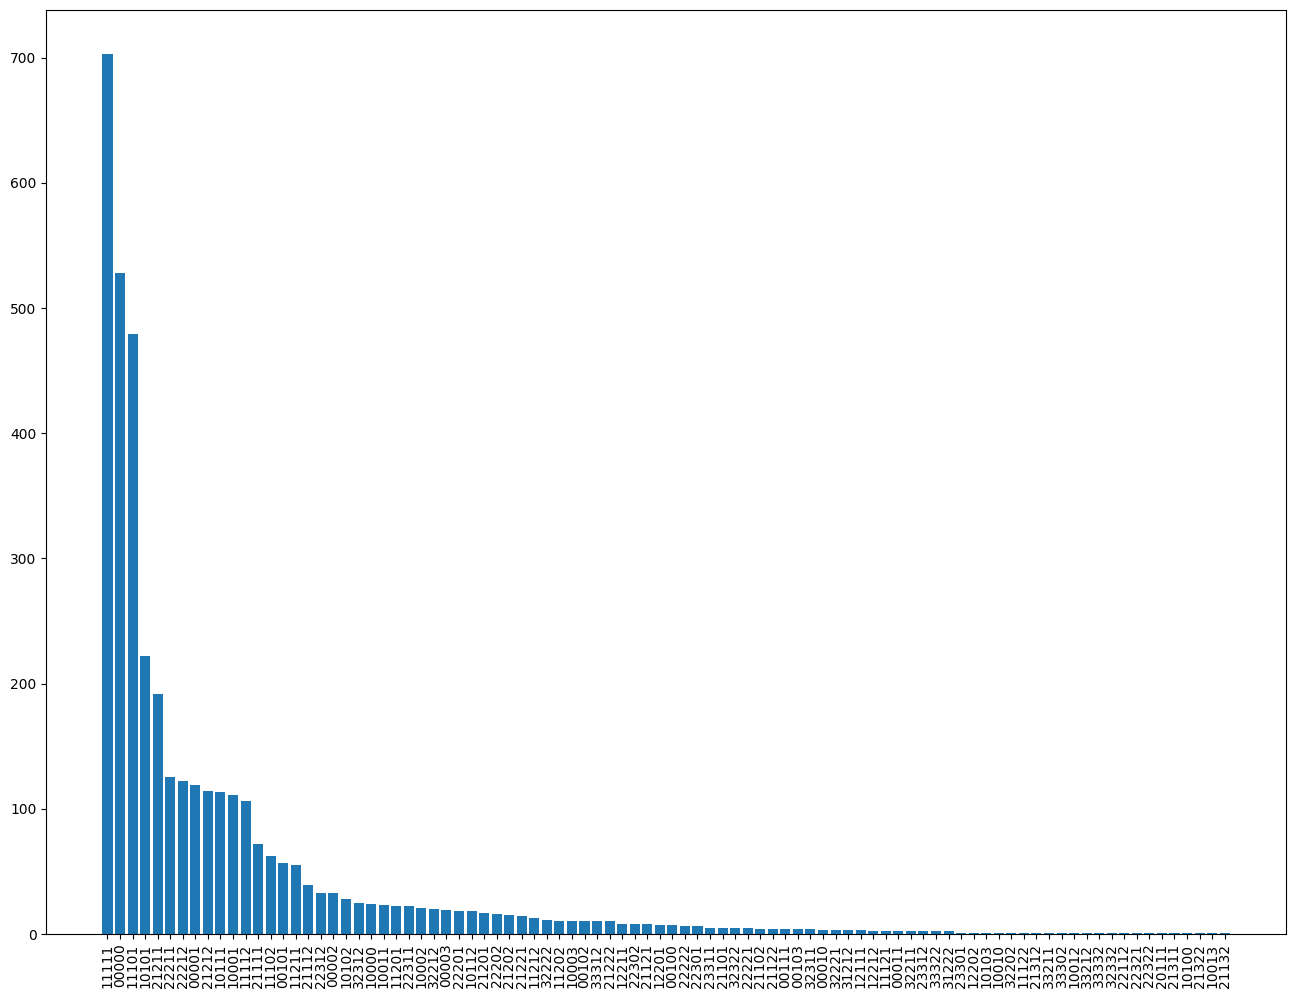

In [97]:
labels = list(sortedBinCount.keys())
count  = list(sortedBinCount.values())

plt.figure(figsize=(16, 12))
plt.bar(labels, count)

_ = plt.xticks(labels, rotation="vertical")

In [82]:
binCount["21132"]

1

In [47]:
fullLabelsArrayBinned[1]

array([2, 2, 3, 1, 2])

In [ ]:
logColumns     = df.columns[3:]
df[logColumns] = np.log(df[logColumns] + 1)

In [ ]:
df['rbis'].hist(bins=50)
plt.title('Histogram of col1')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
transformedDf = df.copy(deep=True)

In [ ]:
# yeoJohnTransformer = PowerTransformer(standardize=True)

# transformedTrainDf['stolenBases'] = pd.DataFrame(yeoJohnTransformer.fit_transform(df['stolenBases'].values.reshape(-1,1)))

In [ ]:
# Applying Quantile Transformation to follow a normal distribution
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=0)
transformedDf['stolenBases'] = quantile_transformer.fit_transform(transformedDf['stolenBases'].values.reshape(-1, 1)).flatten()

In [ ]:
transformedDf['stolenBases'].hist(bins=50)
plt.title('Histogram of col1')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
transformedTrainDf

In [ ]:
numericalDf   = df.select_dtypes(include=np.number)
categoricalDf = df.select_dtypes(exclude=np.number)

dfMean = numericalDf.mean()
dfStd  = numericalDf.std ()

dfNormalized = (numericalDf - dfMean) / dfStd

dfNormalized = pd.concat([categoricalDf, dfNormalized], axis=1)

In [ ]:
labels